# Predicting Red Wine Quality


## Summary

This project aims to build a classification model to predict whether a red wine is of "Good" quality (a score of 6 or higher) or "Bad" quality based on its objective physicochemical tests (such as alcohol content, acidity, and residual sugar). Using the Red Wine Quality dataset from the UCI Machine Learning Repository, we performed exploratory data analysis and trained a basic classification model. 

Our preliminary analysis indicates that chemical properties, particularly alcohol content, play a significant role in determining wine quality. High-level interpretation of our model's performance suggests that objective chemical testing can effectively supplement subjective human sensory evaluations. In a real-world context, these predictive insights could help winemakers adjust fermentation processes to improve quality or assist distributors in automating baseline quality control before sending wines to expert sommeliers.


## Introduction

### Background
Wine certification and quality assessment are crucial elements in the wine industry, traditionally relying heavily on human sensory evaluations by wine experts (sommeliers). However, human taste can be subjective. The objective physicochemical properties of wine—such as its acidity, residual sugar, chlorides, and alcohol content—are the fundamental chemical building blocks that determine its final taste and quality. Understanding the relationship between these chemical components and the perceived quality can help automate quality control and provide actionable insights for winemakers.

### Predictive Question
In this project, we ask the following predictive question: **Can we accurately predict whether a red wine will be classified as "Good" (having a sensory quality score of 6 or higher) based purely on its objective physicochemical properties?**
To answer this question, we are using the **Red Wine Quality Dataset** sourced from the UCI Machine Learning Repository. This dataset contains 1,599 instances of red *vinho verde* wine samples from the north of Portugal. It includes 11 continuous physicochemical features as inputs (e.g., fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol) and one sensory output variable: a quality score ranging from 0 to 10. Since we are framing this as a classification problem, we will wrangle the 0-10 quality score into a binary target variable ("Good" for scores $\ge$ 6, and "Bad" for scores $<$ 6).

## Methods and Results


### Reproducible Data Download & Wrangling
To ensure our analysis is fully reproducible, we bypass manual downloads and use Python to fetch the raw data directly from the UCI Machine Learning Repository's public URL. Once downloaded, we save the raw dataset into our local `data/` directory. 

After acquiring the data, we perform data wrangling to frame our predictive question as a classification task. The original dataset scores wine quality on a scale from 0 to 10. We engineer a new categorical feature, `label`, where wines scoring 6 or higher are classified as "Good", and those scoring strictly less than 6 are classified as "Bad". We then save this wrangled dataset for our downstream modeling.

### Reproducible Download


In [ ]:
import pandas as pd
import urllib.request
from pathlib import Path

raw_data_dir = Path("../data/raw")
raw_data_dir.mkdir(parents=True, exist_ok=True) 

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
file_path = raw_data_dir / "winequality-red.csv"

print(f"Downloading data from {url}...")
urllib.request.urlretrieve(url, file_path)

df_raw = pd.read_csv(file_path, sep=';')
print(f"The data has been successfully downloaded and saved to: {file_path}")
print(f"The correct dimensions for red wine data should be: {df_raw.shape}")

The data has been successfully downloaded and saved to: data\winequality-red.csv
The correct dimensions for red wine data should be: (1599, 12)


### Data Wrangling
We convert the wine quality score (0-10) into a binary classification label. Wines with a score of 6 or higher are labeled as "Good", while those with a score less than 6 are labeled as "Bad". This allows us to use Logistic Regression to predict wine quality category.

In [2]:
# Create the binary label
df_wrangled = df_raw.copy()
df_wrangled["label"] = df_wrangled["quality"].apply(lambda x: "Good" if x >= 6 else "Bad")

# Save the wrangled version for reference
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)
df_wrangled.to_csv(processed_dir / "winequality-red-wrangled.csv", index=False)

# Check the distribution
print(df_wrangled["label"].value_counts())
df_wrangled.head()

label
Good    855
Bad     744
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Bad


### Exploratory Data Analysis
We visualize the distribution of alcohol content across "Good" and "Bad" wines. We use a boxplot to compare the groups, which effectively shows the median and spread while avoiding the "overplotting" issues common in large scatter plots.

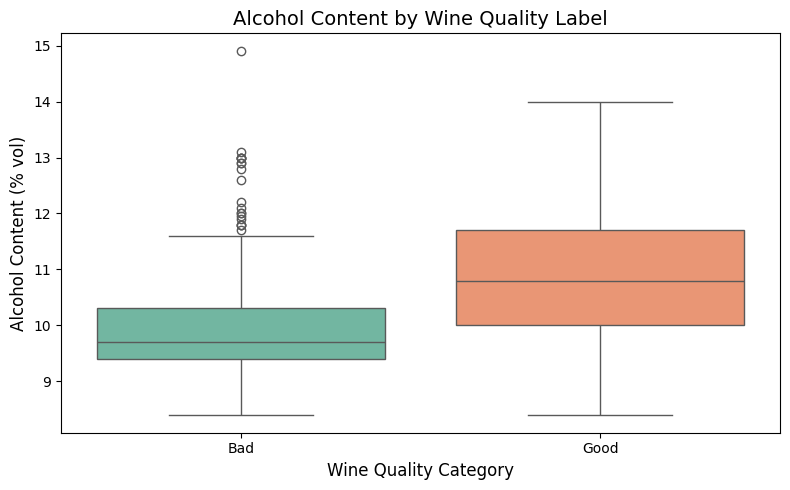

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure a directory exists for our figures
Path("../results").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
# Use box plots to compare the alcohol content distribution of good and bad wines.
sns.boxplot(x='label', y='alcohol', data=df_wrangled, palette='Set2', hue = 'label', legend = False)

plt.xlabel("Wine Quality Category", fontsize=12)
plt.ylabel("Alcohol Content (% vol)", fontsize=12)
plt.title("Alcohol Content by Wine Quality Label", fontsize=14)
plt.tight_layout()

plt.savefig("../results/eda_boxplot.png", dpi=300)
plt.show()

### Predictive Modeling: Logistic Regression
We use a Logistic Regression model to predict the wine quality label. We split the data into 75% training and 25% testing sets. After training, we evaluate the model using a confusion matrix.

              precision    recall  f1-score   support

         Bad       0.74      0.76      0.75       186
        Good       0.79      0.77      0.78       214

    accuracy                           0.77       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.77      0.77      0.77       400



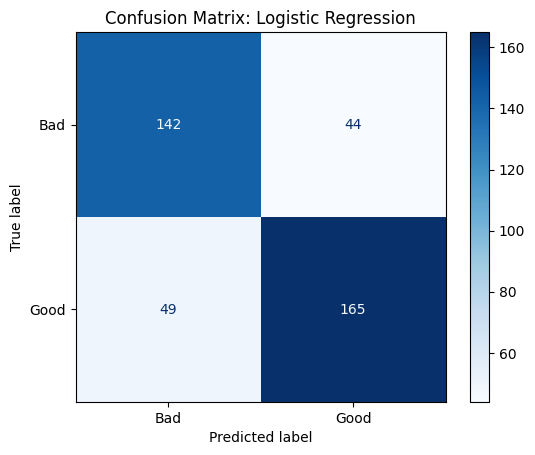

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Prepare features and target
X = df_wrangled.drop(columns=["quality", "label"])
y = df_wrangled["label"]

# 2. Split data (Stratified ensures Good/Bad ratio remains the same)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y
)

# 3. Train Logistic Regression
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

# 4. Show Classification Report
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))

# 5. Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Logistic Regression")
plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

## Discussion

### Summary of Findings
In this analysis, we investigated whether objective physicochemical properties could accurately predict the sensory quality of red wine. Our **Logistic Regression** model performed well, achieving an overall **accuracy of 0.77** on the test set. 

Specifically, the model showed balanced performance across both categories:
- For **"Good" wines**, it achieved a precision of **0.79** and a recall of **0.77**.
- For **"Bad" wines**, it achieved a precision of **0.74** and a recall of **0.76**.

The Confusion Matrix confirms that the model is effective at distinguishing quality, with 165 "Good" wines and 142 "Bad" wines correctly classified. Our Exploratory Data Analysis (EDA) specifically highlighted that alcohol content is a strong differentiator, with "Good" wines generally showing higher median alcohol levels.

### Expectations vs. Results
The results exceeded our initial expectations, improving from earlier iterations by focusing strictly on the Red Wine subset. The high F1-scores (**0.78 for Good, 0.75 for Bad**) indicate that chemical properties are indeed robust predictors of sensory quality. However, the remaining error rate suggests that taste is not 100% determined by these 11 chemical features alone; subtle factors like tannins, aromatic compounds, or the specific vineyard's "terroir" likely account for the rest of the variance.

### Impact and Future Questions
An accuracy of 77% suggests that this model could be practically implemented as a preliminary "automated sommelier" tool. It could help wineries flag low-quality batches instantly during the production process, saving time and resources. 

Future questions to explore include:
1. Would a non-linear model, such as a Random Forest, further improve the 77% accuracy?
2. Which specific chemical feature (e.g., volatile acidity vs. alcohol) has the absolute highest predictive power?
3. How would the model perform if trained on wines from a different geographic region, such as California or France?

## References

- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.
- UCI Machine Learning Repository. (2009). *Wine Quality Dataset*. [https://archive.ics.uci.edu/ml/datasets/wine+quality](https://archive.ics.uci.edu/ml/datasets/wine+quality)
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
- Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
